# 02. Forensic Time-Series Exploration

This notebook audits the AquaSense AI data like a production wastewater telemetry stream.
It checks time coverage, sampling consistency, missingness, sensor validity, incidents,
compliance states, prediction targets, lab-vs-estimate reliability, seasonality, Fourier
patterns, and early-warning relationships.

## 1. Setup and Visual Style

Use one consistent plotting style and palette across the notebook so charts are readable
and presentation-ready.

In [1]:
from pathlib import Path
import os
import json
import warnings

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib-cache")
(ROOT / ".matplotlib-cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.3f}".format)

COLORS = {
    "blue": "#2563EB",
    "cyan": "#0891B2",
    "green": "#16A34A",
    "amber": "#D97706",
    "red": "#DC2626",
    "purple": "#7C3AED",
    "slate": "#475569",
    "gray": "#CBD5E1",
}
STATUS_COLORS = {"GREEN": COLORS["green"], "AMBER": COLORS["amber"], "RED": COLORS["red"]}
EVENT_COLORS = {
    "normal": "#94A3B8",
    "organic_overload": "#7C3AED",
    "solids_washout": "#D97706",
    "acid_spill": "#DC2626",
    "alkali_spill": "#2563EB",
    "ammonia_spike": "#16A34A",
    "thermal_discharge": "#EA580C",
    "sensor_drift": "#0891B2",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (13, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.edgecolor": "#CBD5E1",
    "grid.color": "#E2E8F0",
    "grid.linewidth": 0.8,
})

def finish_plot(title, xlabel=None, ylabel=None, legend=True):
    ax = plt.gca()
    ax.set_title(title, weight="bold", pad=14)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if legend and ax.get_legend() is not None:
        ax.legend(frameon=True, framealpha=0.95)
    sns.despine()
    plt.tight_layout()

ROOT

PosixPath('/Users/dannyyy/Documents/AQUASENSE AI')

## 2. Load Pipeline Artifacts

Load the direct sensor stream, operational compliance dataset, model-ready dataset,
lab results, soft-sensor estimates, and consent limits created by the acquisition notebook.

In [2]:
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
CONFIG = ROOT / "packages" / "shared" / "config"

sensors = pd.read_csv(RAW / "direct_sensor_readings.csv", parse_dates=["timestamp"])
lab = pd.read_csv(RAW / "lab_results.csv", parse_dates=["timestamp"])
estimates = pd.read_csv(PROCESSED / "soft_sensor_estimates.csv", parse_dates=["timestamp"])
operational = pd.read_csv(PROCESSED / "operational_compliance_dataset.csv", parse_dates=["timestamp"])
model_df = pd.read_csv(PROCESSED / "compliance_training_dataset.csv", parse_dates=["timestamp"])
validation = pd.read_csv(PROCESSED / "lab_vs_estimate_validation.csv", parse_dates=["timestamp"])
metrics = pd.read_csv(PROCESSED / "lab_vs_estimate_metrics.csv", index_col=0)

with open(CONFIG / "demo_limits.json") as f:
    consent_limits = json.load(f)

{
    "sensors": sensors.shape,
    "lab": lab.shape,
    "estimates": estimates.shape,
    "operational": operational.shape,
    "model_df": model_df.shape,
}

/var/folders/g_/z48b63157s31wgpzgh35q90c0000gn/T/ipykernel_3376/118057738.py:9: DtypeWarning: Columns (0: breached_parameters) have mixed types. Specify dtype option on import or set low_memory=False.
  model_df = pd.read_csv(PROCESSED / "compliance_training_dataset.csv", parse_dates=["timestamp"])


{'sensors': (8640, 13),
 'lab': (135, 7),
 'estimates': (8640, 8),
 'operational': (8640, 40),
 'model_df': (8630, 64)}

## 3. Schema and Coverage Audit

Confirm row counts, time ranges, duplicate timestamps, available fields, and whether each
dataset matches the expected 5-minute telemetry cadence.

In [3]:
def coverage(frame, name):
    diffs = frame["timestamp"].sort_values().diff().dropna()
    return {
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "start": frame["timestamp"].min(),
        "end": frame["timestamp"].max(),
        "duplicate_timestamps": frame["timestamp"].duplicated().sum(),
        "most_common_interval": diffs.mode().iloc[0] if len(diffs) else pd.NaT,
        "unique_intervals": diffs.nunique(),
    }

pd.DataFrame([
    coverage(sensors, "direct sensors"),
    coverage(lab, "lab results"),
    coverage(estimates, "soft-sensor estimates"),
    coverage(operational, "operational compliance"),
    coverage(model_df, "model-ready"),
])

,dataset,rows,columns,start,end,duplicate_timestamps,most_common_interval,unique_intervals
0,direct sensors,8640,13,2026-05-01,2026-05-30 23:55:00,0,0 days 00:05:00,1
1,lab results,135,7,2026-05-01,2026-05-30 18:00:00,0,0 days 06:00:00,16
2,soft-sensor estimates,8640,8,2026-05-01,2026-05-30 23:55:00,0,0 days 00:05:00,1
3,operational compliance,8640,40,2026-05-01,2026-05-30 23:55:00,0,0 days 00:05:00,1
4,model-ready,8630,64,2026-05-01,2026-05-30 23:55:00,0,0 days 00:05:00,2


## 4. Sampling Frequency Forensics

A stable 5-minute cadence is important because the 15/30/60-minute prediction labels depend
on a consistent number of rows per future window.

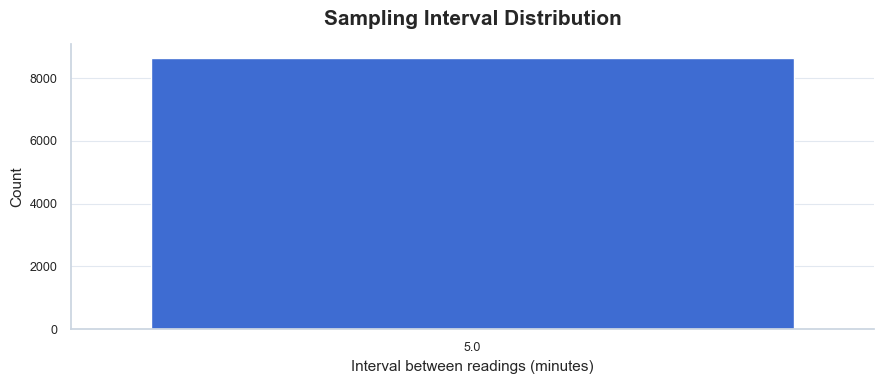

timestamp
5.000    8639
Name: count, dtype: int64

In [4]:
intervals = sensors["timestamp"].sort_values().diff().dropna().dt.total_seconds().div(60)
interval_counts = intervals.value_counts().sort_index()

plt.figure(figsize=(9, 4))
sns.barplot(x=interval_counts.index.astype(str), y=interval_counts.values, color=COLORS["blue"])
finish_plot("Sampling Interval Distribution", "Interval between readings (minutes)", "Count", legend=False)
plt.show()

interval_counts

## 5. Missingness Audit

Missing data is not only a modelling problem; it can be a sensor outage, communication issue,
calibration event, or operational risk. This section shows where missingness appears.

In [5]:
sensor_cols = [
    "ph", "temperature_c", "flow_rate_lps", "turbidity_ntu",
    "conductivity_us_cm", "dissolved_oxygen_mg_l", "orp_mv",
    "ammonia_mg_l", "uv254_abs",
]

missing = sensors[sensor_cols].isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(sensors) * 100).round(3)
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
ph,10,0.116
turbidity_ntu,10,0.116
uv254_abs,10,0.116
temperature_c,0,0.000
flow_rate_lps,0,0.000
conductivity_us_cm,0,0.000
dissolved_oxygen_mg_l,0,0.000
orp_mv,0,0.000
ammonia_mg_l,0,0.000


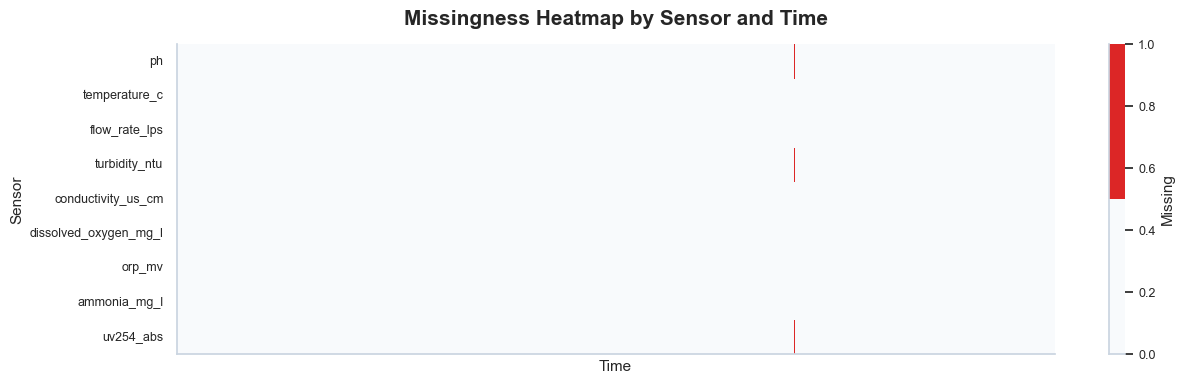

In [6]:
missing_by_time = sensors.set_index("timestamp")[sensor_cols].isna().astype(int)

plt.figure(figsize=(13, 4))
sns.heatmap(
    missing_by_time.T,
    cmap=sns.color_palette(["#F8FAFC", COLORS["red"]], as_cmap=True),
    cbar_kws={"label": "Missing"},
    xticklabels=False,
    yticklabels=True,
)
finish_plot("Missingness Heatmap by Sensor and Time", "Time", "Sensor", legend=False)
plt.show()

## 6. Sensor Validity Checks

Check for physically impossible or suspicious values. Production systems should turn these
into data-quality alerts before model inference.

In [7]:
validity_rules = {
    "ph": sensors["ph"].between(0, 14) | sensors["ph"].isna(),
    "temperature_c": sensors["temperature_c"].between(0, 80),
    "flow_rate_lps": sensors["flow_rate_lps"] >= 0,
    "turbidity_ntu": sensors["turbidity_ntu"].ge(0) | sensors["turbidity_ntu"].isna(),
    "conductivity_us_cm": sensors["conductivity_us_cm"] >= 0,
    "dissolved_oxygen_mg_l": sensors["dissolved_oxygen_mg_l"].between(0, 20),
    "orp_mv": sensors["orp_mv"].between(-500, 700),
    "ammonia_mg_l": sensors["ammonia_mg_l"] >= 0,
    "uv254_abs": sensors["uv254_abs"].ge(0) | sensors["uv254_abs"].isna(),
}

validity = pd.DataFrame({
    "sensor": validity_rules.keys(),
    "invalid_count": [(~rule).sum() for rule in validity_rules.values()],
})
validity["invalid_pct"] = (validity["invalid_count"] / len(sensors) * 100).round(3)
validity.sort_values("invalid_count", ascending=False)

,sensor,invalid_count,invalid_pct
0,ph,0,0.000
1,temperature_c,0,0.000
2,flow_rate_lps,0,0.000
3,turbidity_ntu,0,0.000
4,conductivity_us_cm,0,0.000
5,dissolved_oxygen_mg_l,0,0.000
6,orp_mv,0,0.000
7,ammonia_mg_l,0,0.000
8,uv254_abs,0,0.000


## 7. Descriptive Statistics

Summary statistics give a quick view of central tendency, spread, and extreme values.

In [8]:
sensors[sensor_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
ph,"8,630.000",7.403,0.212,5.399,7.024,7.103,7.402,7.704,7.781,10.224
temperature_c,"8,640.000",26.196,2.296,19.993,21.559,22.453,26.110,29.901,30.909,49.216
flow_rate_lps,"8,640.000",51.735,9.041,28.764,33.739,37.016,51.875,66.395,69.123,73.476
turbidity_ntu,"8,630.000",74.385,18.728,26.917,39.825,46.087,75.765,101.247,110.517,259.845
conductivity_us_cm,"8,640.000","1,391.176",133.545,"1,053.827","1,129.613","1,180.490","1,399.694","1,594.005","1,653.436","1,986.299"
dissolved_oxygen_mg_l,"8,640.000",5.463,0.405,4.121,4.549,4.808,5.461,6.118,6.379,6.830
orp_mv,"8,640.000",158.098,17.143,99.993,119.956,130.190,158.143,186.456,196.473,221.783
ammonia_mg_l,"8,640.000",23.759,8.703,9.196,13.084,14.913,24.576,31.436,33.850,218.100
uv254_abs,"8,630.000",0.547,0.078,0.304,0.392,0.426,0.549,0.665,0.703,1.087


## 8. Direct Sensor Time-Series Overview

Each direct sensor is plotted separately at full width so the pattern is readable.
These charts show normal operating cycles plus incident-driven spikes, drops, or drifts.

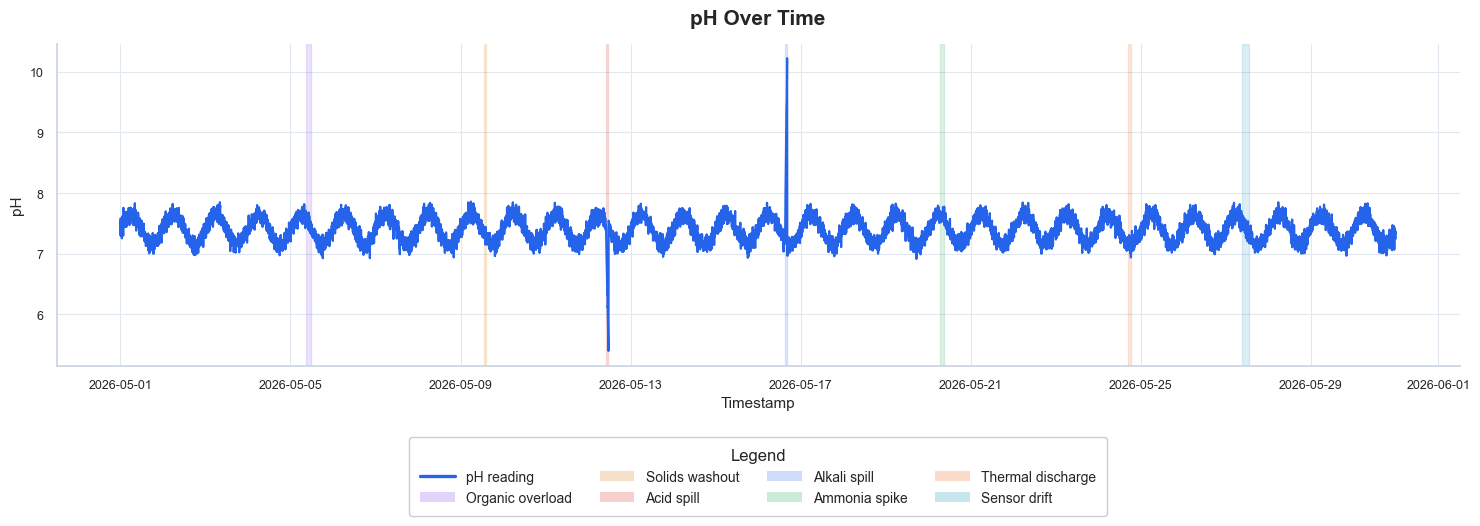

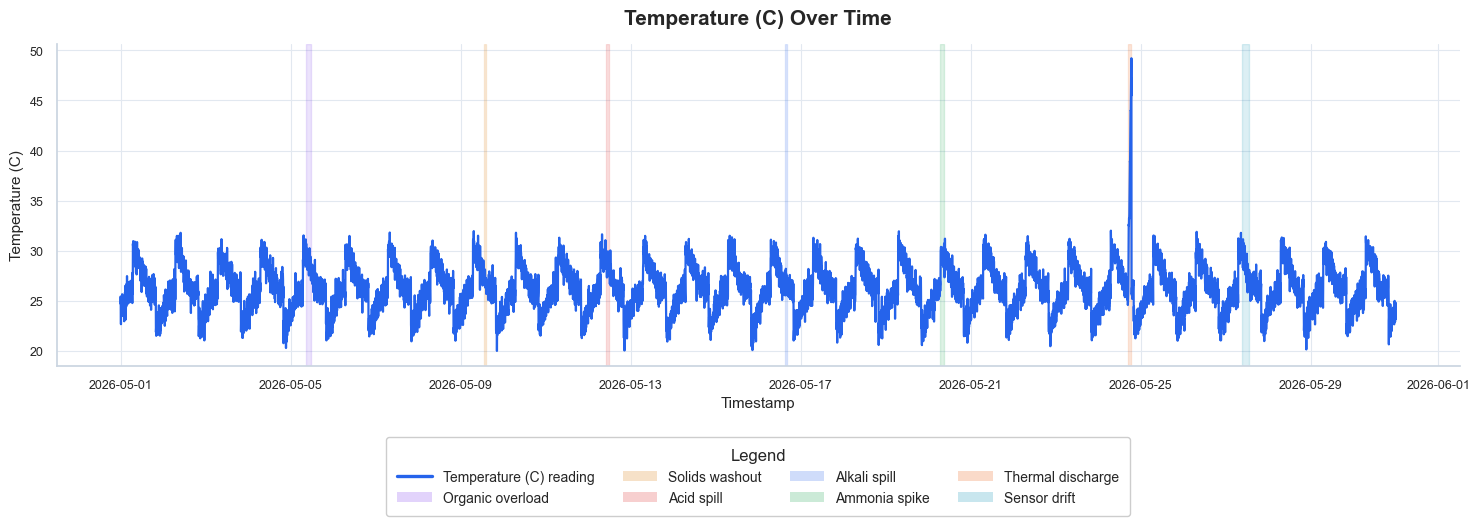

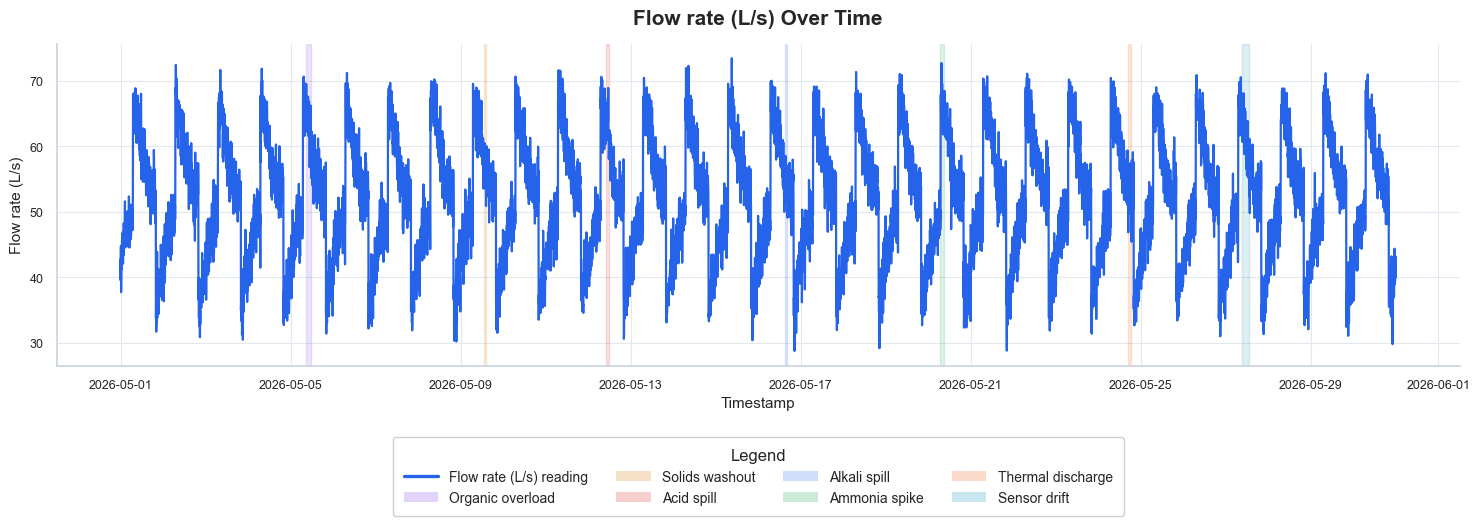

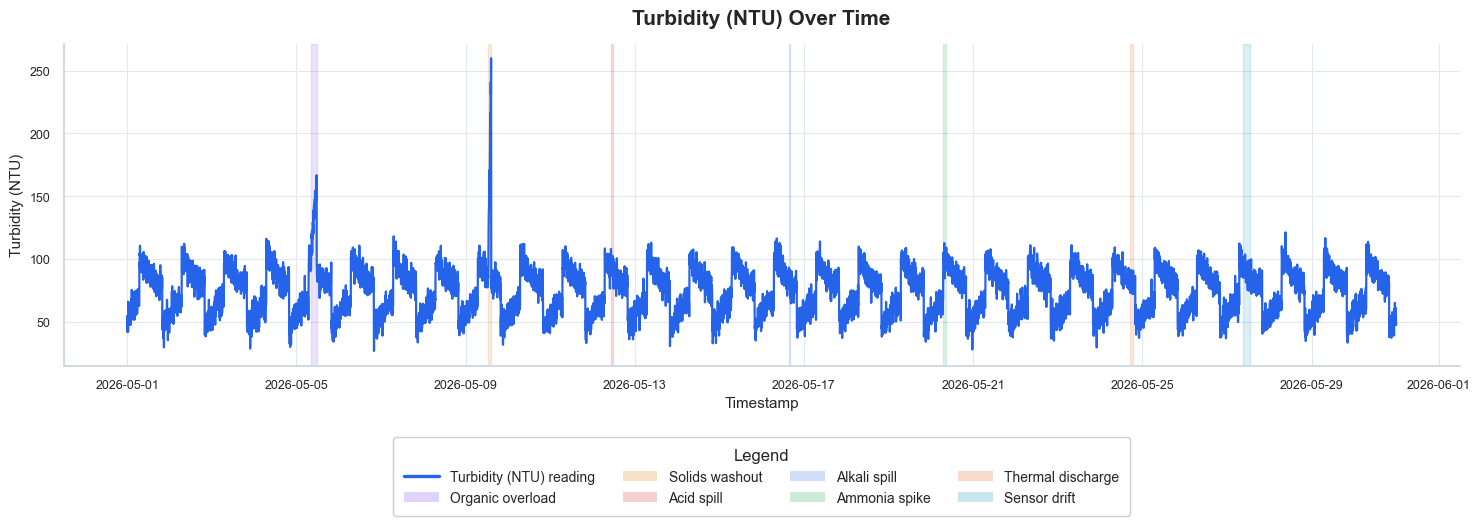

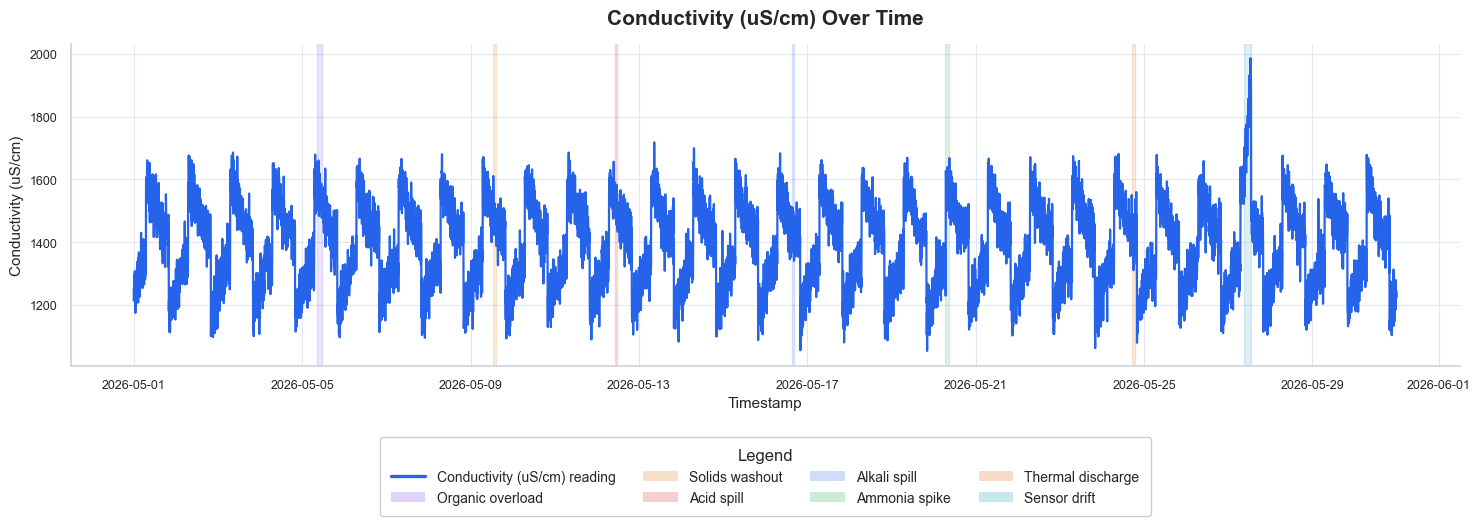

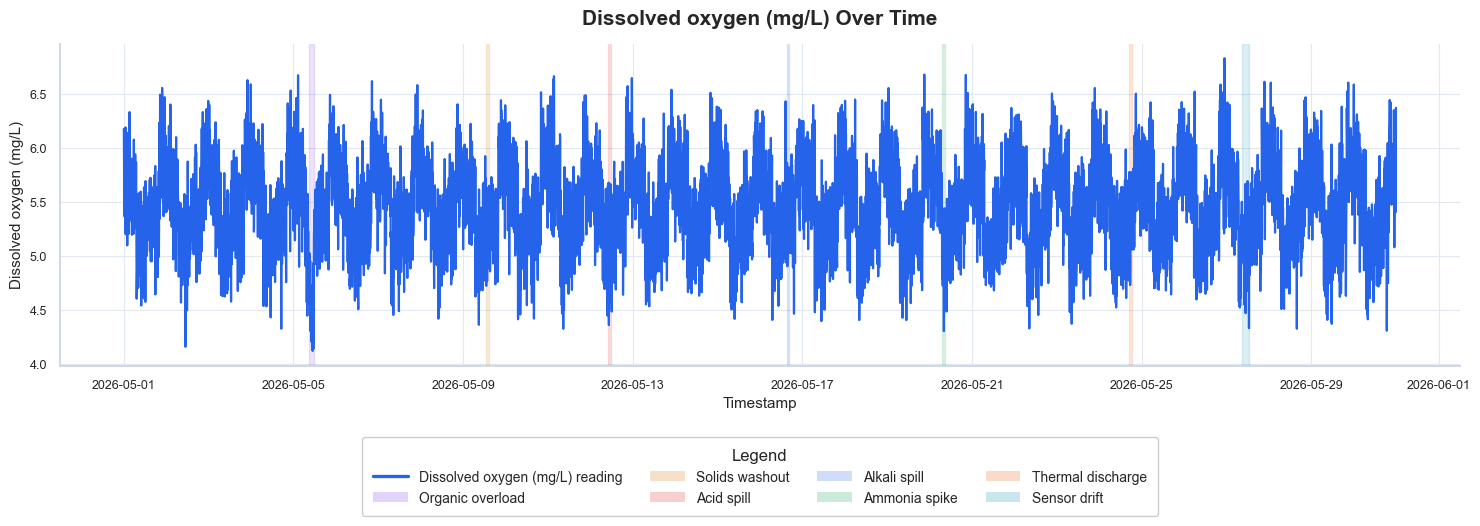

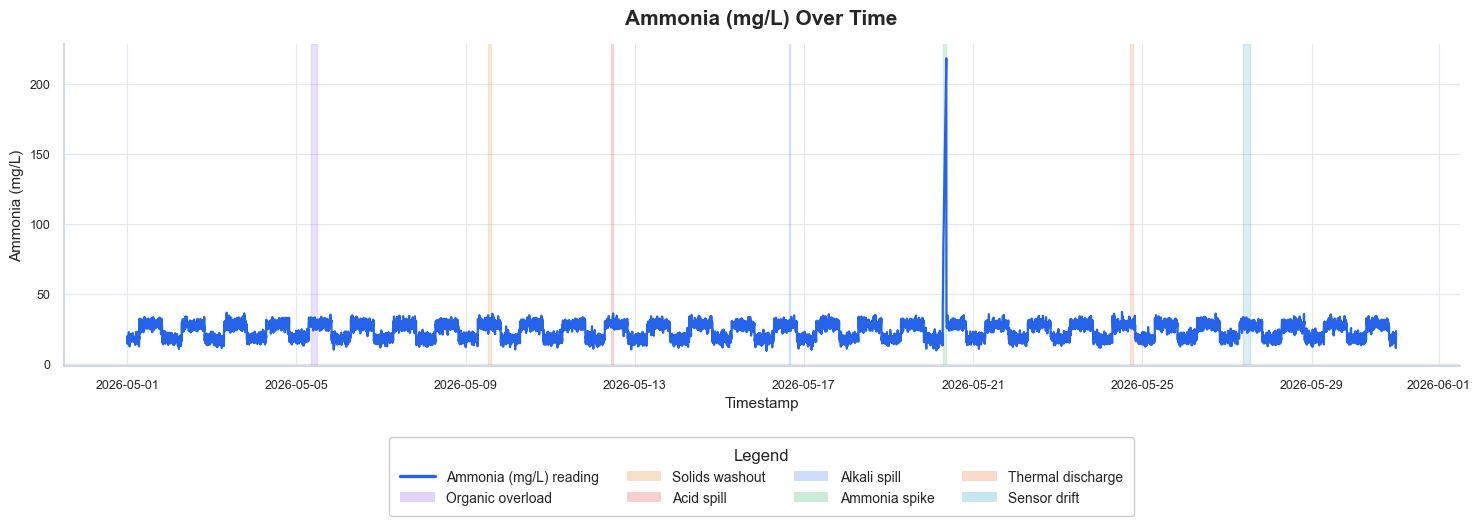

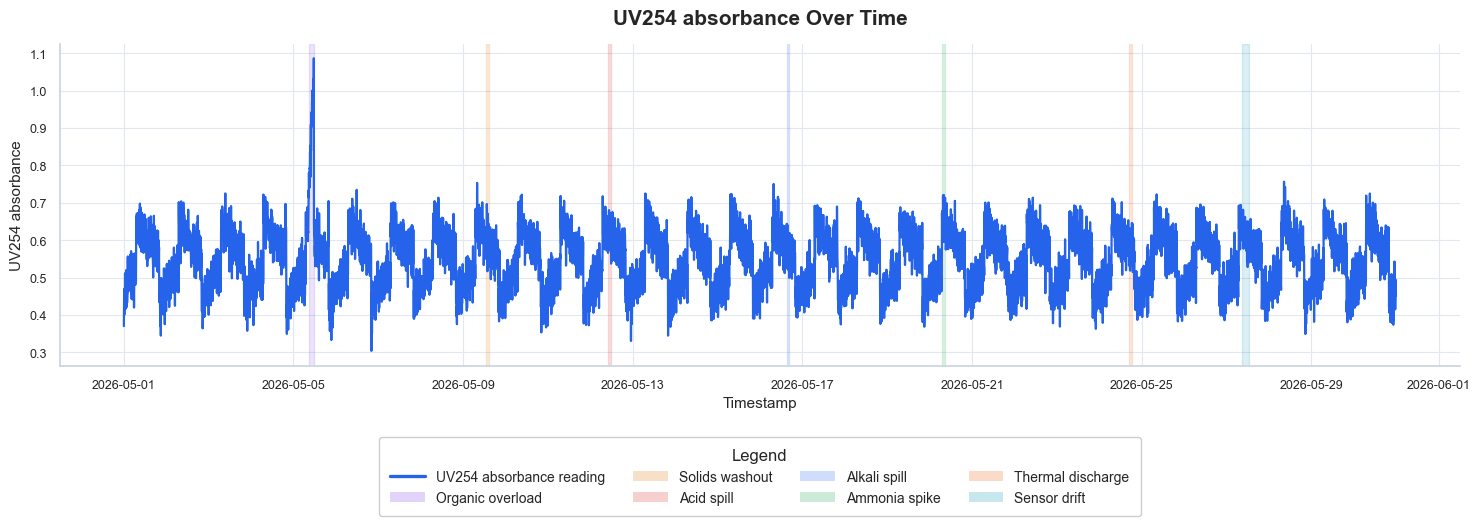

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_cols = [
    "ph", "temperature_c", "flow_rate_lps", "turbidity_ntu",
    "conductivity_us_cm", "dissolved_oxygen_mg_l", "ammonia_mg_l", "uv254_abs",
]

sensor_labels = {
    "ph": "pH",
    "temperature_c": "Temperature (C)",
    "flow_rate_lps": "Flow rate (L/s)",
    "turbidity_ntu": "Turbidity (NTU)",
    "conductivity_us_cm": "Conductivity (uS/cm)",
    "dissolved_oxygen_mg_l": "Dissolved oxygen (mg/L)",
    "ammonia_mg_l": "Ammonia (mg/L)",
    "uv254_abs": "UV254 absorbance",
}

incident_labels = {
    "organic_overload": "Organic overload",
    "solids_washout": "Solids washout",
    "acid_spill": "Acid spill",
    "alkali_spill": "Alkali spill",
    "ammonia_spike": "Ammonia spike",
    "thermal_discharge": "Thermal discharge",
    "sensor_drift": "Sensor drift",
}

incident_spans = (
    sensors[sensors["event_type"] != "normal"]
    .groupby("event_type")
    .agg(start=("timestamp", "min"), end=("timestamp", "max"))
    .sort_values("start")
)

incident_legend = [
    Patch(
        facecolor=EVENT_COLORS.get(event, COLORS["gray"]),
        edgecolor="none",
        alpha=0.22,
        label=incident_labels.get(event, event.replace("_", " ").title()),
    )
    for event in incident_spans.index
]

for col in plot_cols:
    fig, ax = plt.subplots(figsize=(15, 5.2))
    ax.plot(
        sensors["timestamp"],
        sensors[col],
        color=COLORS["blue"],
        linewidth=1.6,
        label=sensor_labels[col],
        zorder=3,
    )

    for event, row in incident_spans.iterrows():
        ax.axvspan(
            row["start"],
            row["end"],
            color=EVENT_COLORS.get(event, COLORS["gray"]),
            alpha=0.14,
            zorder=1,
        )

    sensor_handle = Line2D(
        [0], [0],
        color=COLORS["blue"],
        linewidth=2.4,
        label=f"{sensor_labels[col]} reading",
    )
    ax.legend(
        handles=[sensor_handle, *incident_legend],
        title="Legend",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=4,
        frameon=True,
        framealpha=0.98,
        borderpad=0.8,
        handlelength=2.5,
    )

    finish_plot(
        f"{sensor_labels[col]} Over Time",
        "Timestamp",
        sensor_labels[col],
        legend=False,
    )
    plt.subplots_adjust(bottom=0.28)
    plt.show()


## 9. Incident Timeline

Incidents are simulated causes of abnormal behaviour. In production, these would be mapped
from operator logs, SCADA alarms, maintenance records, and incident investigations.

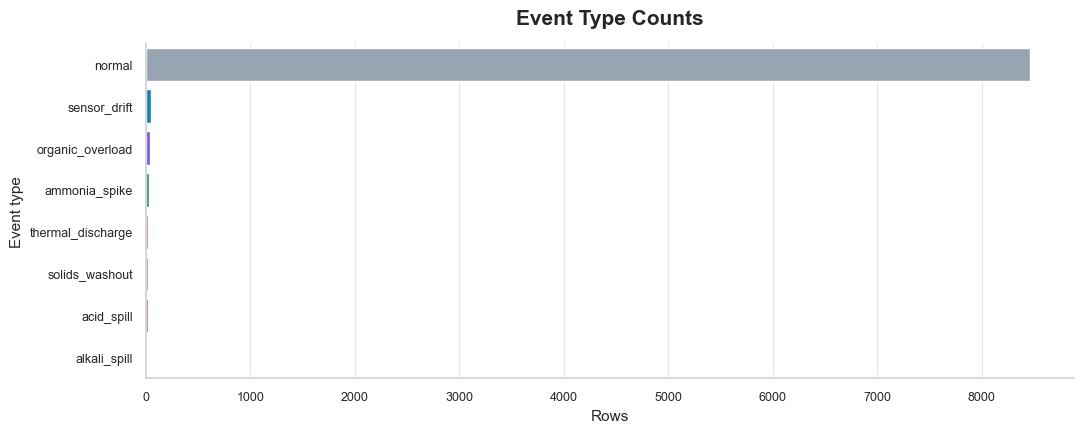

,start,end,rows
event_type,,,
organic_overload,2026-05-05 08:30:00,2026-05-05 11:30:00,37
solids_washout,2026-05-09 13:00:00,2026-05-09 14:30:00,19
acid_spill,2026-05-12 10:15:00,2026-05-12 11:30:00,16
alkali_spill,2026-05-16 15:20:00,2026-05-16 16:20:00,13
ammonia_spike,2026-05-20 06:45:00,2026-05-20 08:45:00,25
thermal_discharge,2026-05-24 17:00:00,2026-05-24 18:40:00,21
sensor_drift,2026-05-27 09:00:00,2026-05-27 13:00:00,49


In [10]:
incident_counts = sensors["event_type"].value_counts()

plt.figure(figsize=(11, 4.5))
sns.barplot(
    x=incident_counts.values,
    y=incident_counts.index,
    palette=[EVENT_COLORS.get(x, COLORS["slate"]) for x in incident_counts.index],
)
finish_plot("Event Type Counts", "Rows", "Event type", legend=False)
plt.show()

incident_windows = (
    sensors[sensors["event_type"] != "normal"]
    .groupby("event_type")
    .agg(start=("timestamp", "min"), end=("timestamp", "max"), rows=("timestamp", "size"))
    .sort_values("start")
)
incident_windows

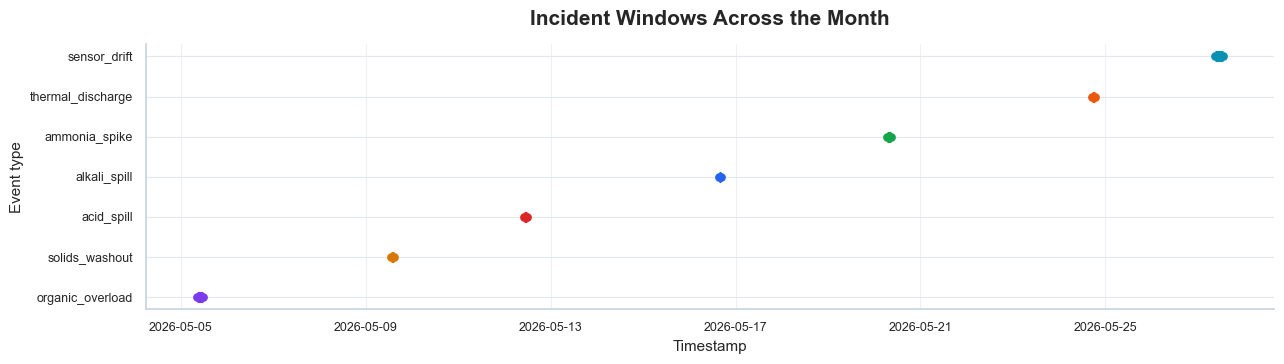

In [11]:
fig, ax = plt.subplots(figsize=(13, 3.8))
for event, row in incident_windows.iterrows():
    ax.hlines(event, row["start"], row["end"], color=EVENT_COLORS.get(event, COLORS["slate"]), linewidth=8)
    ax.scatter([row["start"], row["end"]], [event, event], color=EVENT_COLORS.get(event, COLORS["slate"]), s=28)

ax.set_title("Incident Windows Across the Month", weight="bold", pad=14)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Event type")
ax.grid(axis="x", alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

## 10. Event Impact Profiles

Compare sensor medians during normal operation versus incidents. This helps confirm that
injected causes create interpretable physical effects.

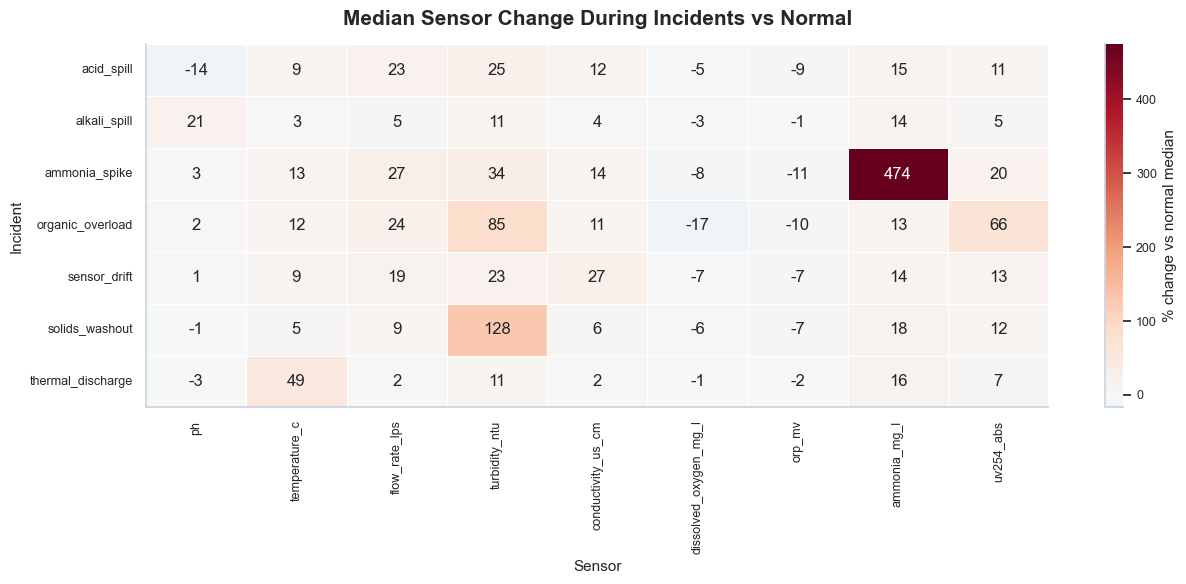

In [12]:
event_profile = sensors.groupby("event_type")[sensor_cols].median()
baseline = event_profile.loc["normal"]
relative_change = ((event_profile - baseline) / baseline.replace(0, np.nan) * 100).drop(index="normal")

plt.figure(figsize=(13, 6))
sns.heatmap(
    relative_change,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "% change vs normal median"},
)
finish_plot("Median Sensor Change During Incidents vs Normal", "Sensor", "Incident", legend=False)
plt.show()

## 11. Compliance Status Forensics

Show how often the rules engine classifies the site as GREEN, AMBER, or RED.

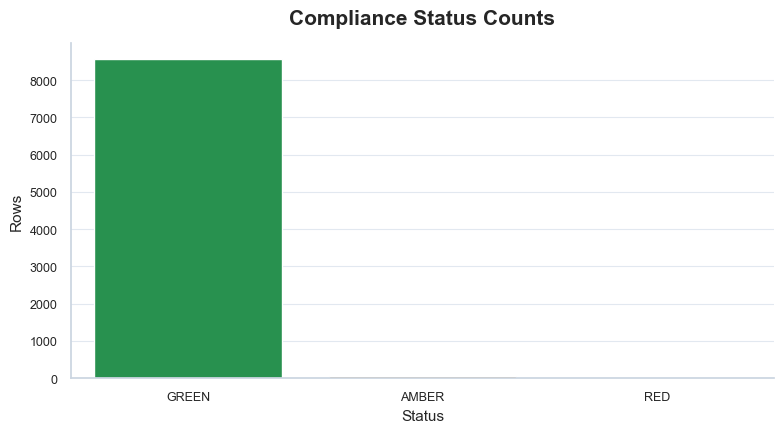

compliance_status
GREEN   99.016
AMBER    0.602
RED      0.382
Name: status_pct, dtype: float64

In [13]:
status_counts = operational["compliance_status"].value_counts().reindex(["GREEN", "AMBER", "RED"]).fillna(0)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette=[STATUS_COLORS[s] for s in status_counts.index],
)
finish_plot("Compliance Status Counts", "Status", "Rows", legend=False)
plt.show()

(status_counts / status_counts.sum() * 100).round(3).rename("status_pct")

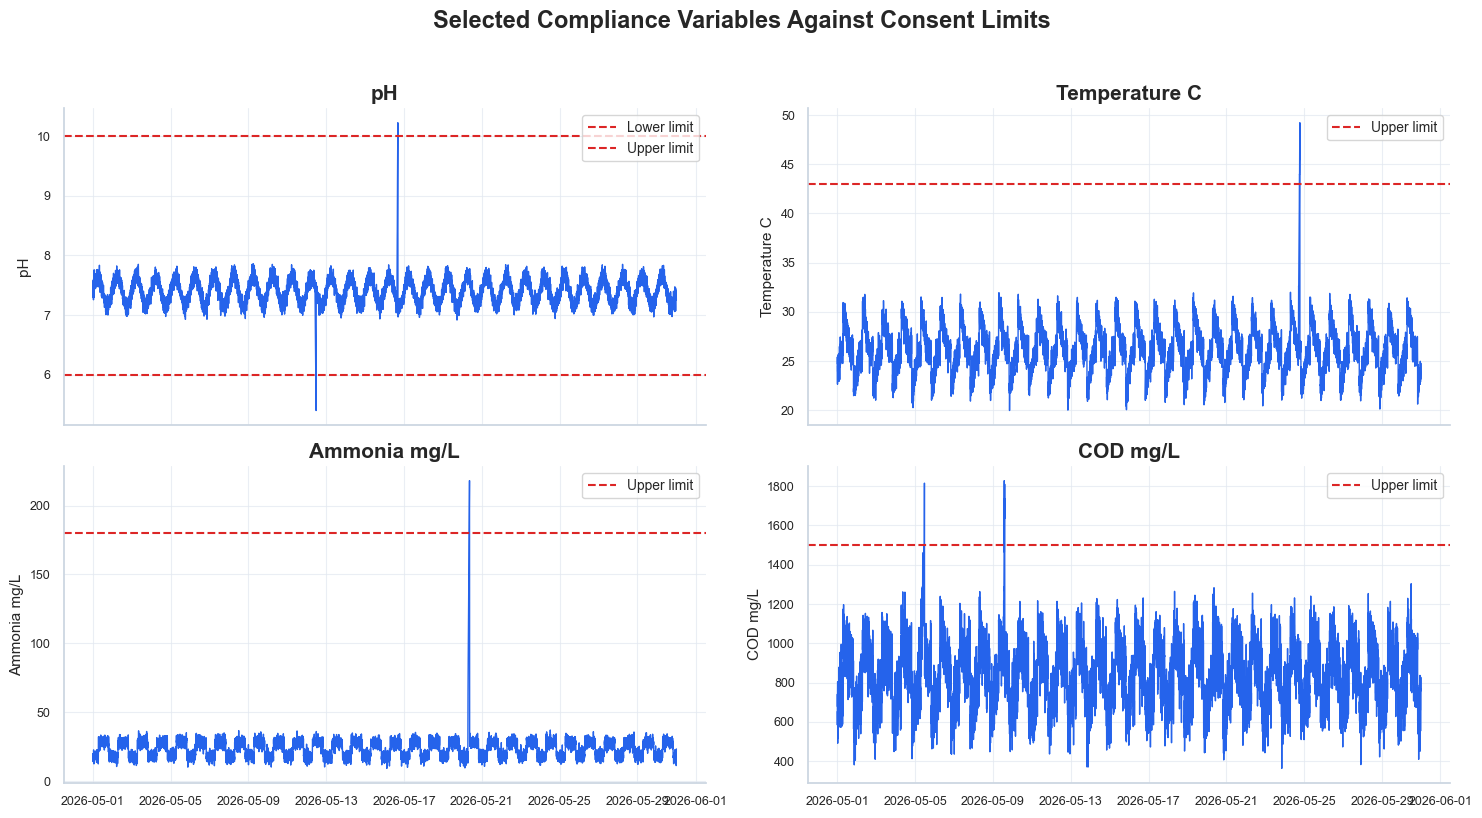

In [14]:
limits = consent_limits["limits"]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
limit_plots = [
    ("ph", "pH", limits["ph_min"], limits["ph_max"]),
    ("temperature_c", "Temperature C", None, limits["temperature_max_c"]),
    ("ammonia_mg_l_for_compliance", "Ammonia mg/L", None, limits["ammonia_max_mg_l"]),
    ("cod_mg_l_for_compliance", "COD mg/L", None, limits["cod_max_mg_l"]),
]

for ax, (col, label, low, high) in zip(axes.ravel(), limit_plots):
    ax.plot(operational["timestamp"], operational[col], color=COLORS["blue"], linewidth=1)
    if low is not None:
        ax.axhline(low, color=COLORS["red"], linestyle="--", linewidth=1.5, label="Lower limit")
    if high is not None:
        ax.axhline(high, color=COLORS["red"], linestyle="--", linewidth=1.5, label="Upper limit")
    ax.set_title(label, weight="bold")
    ax.set_ylabel(label)
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.7)

fig.suptitle("Selected Compliance Variables Against Consent Limits", fontsize=17, weight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

## 12. Breach Drivers

Identify which parameters are most often closest to their consent limit. This informs
dashboard explanations and recommended actions.

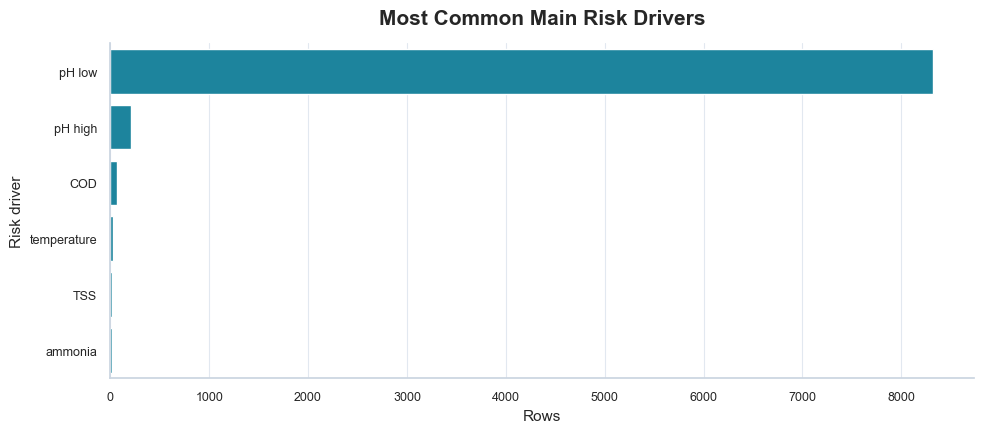

main_risk_driver
pH low         8320
pH high         204
COD              64
temperature      22
TSS              18
ammonia          12
Name: count, dtype: int64

In [15]:
driver_counts = operational["main_risk_driver"].value_counts()

plt.figure(figsize=(10, 4.5))
sns.barplot(x=driver_counts.values, y=driver_counts.index, color=COLORS["cyan"])
finish_plot("Most Common Main Risk Drivers", "Rows", "Risk driver", legend=False)
plt.show()

driver_counts

## 13. Prediction Target Balance

Target balance tells us whether breach prediction is rare-event modelling.
It also helps set expectations for precision, recall, and false-alarm tradeoffs later.

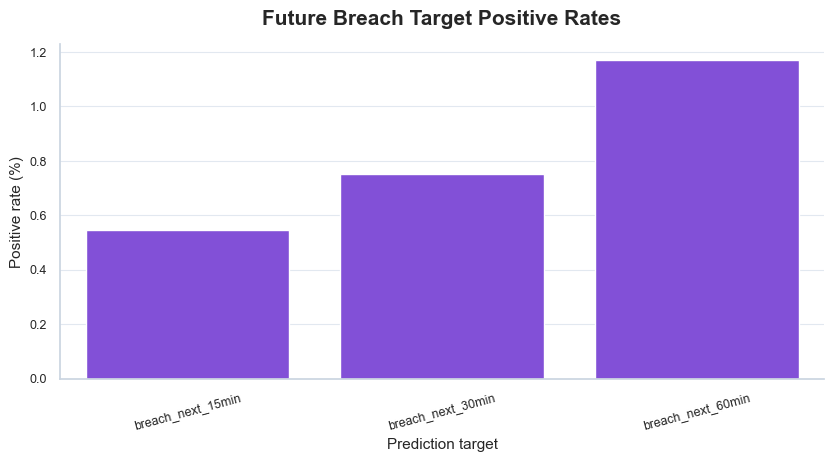

breach_next_15min   0.545
breach_next_30min   0.753
breach_next_60min   1.170
Name: positive_rate_pct, dtype: float64

In [16]:
target_cols = ["breach_next_15min", "breach_next_30min", "breach_next_60min"]
target_rates = model_df[target_cols].mean().mul(100).round(3)

plt.figure(figsize=(8.5, 4.5))
sns.barplot(x=target_rates.index, y=target_rates.values, color=COLORS["purple"])
finish_plot("Future Breach Target Positive Rates", "Prediction target", "Positive rate (%)", legend=False)
plt.xticks(rotation=15)
plt.show()

target_rates.rename("positive_rate_pct")

## 14. Lab vs Estimate Reliability

COD, BOD, and TSS are not treated as simple real-time probe values. This section compares
soft-sensor estimates against sparse lab-confirmed measurements.

In [17]:
metrics

,MAE,RMSE,MAPE_%,R2
COD,46.017,57.173,5.555,0.909
BOD,29.209,36.749,7.356,0.883
TSS,15.700,20.429,4.445,0.971


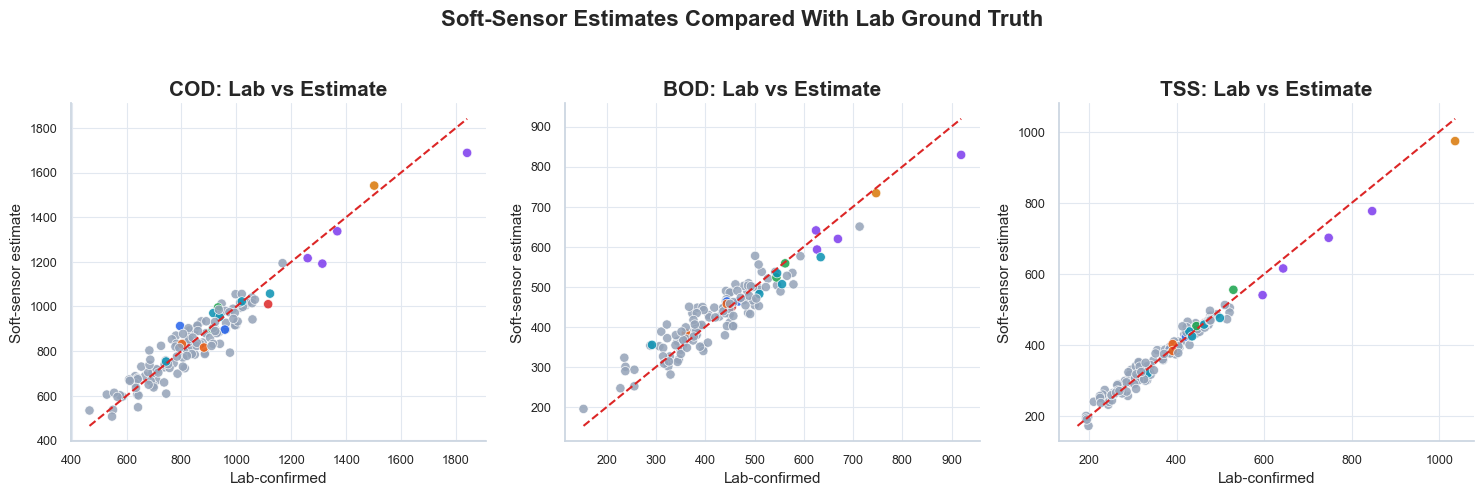

In [18]:
pairs = [
    ("lab_cod_mg_l", "estimated_cod_mg_l", "COD"),
    ("lab_bod_mg_l", "estimated_bod_mg_l", "BOD"),
    ("lab_tss_mg_l", "estimated_tss_mg_l", "TSS"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (actual, predicted, label) in zip(axes, pairs):
    sns.scatterplot(
        data=validation,
        x=actual,
        y=predicted,
        hue="event_type",
        palette=EVENT_COLORS,
        s=45,
        alpha=0.85,
        ax=ax,
        legend=False,
    )
    low = min(validation[actual].min(), validation[predicted].min())
    high = max(validation[actual].max(), validation[predicted].max())
    ax.plot([low, high], [low, high], color=COLORS["red"], linestyle="--", linewidth=1.5)
    ax.set_title(f"{label}: Lab vs Estimate", weight="bold")
    ax.set_xlabel("Lab-confirmed")
    ax.set_ylabel("Soft-sensor estimate")

fig.suptitle("Soft-Sensor Estimates Compared With Lab Ground Truth", fontsize=16, weight="bold", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

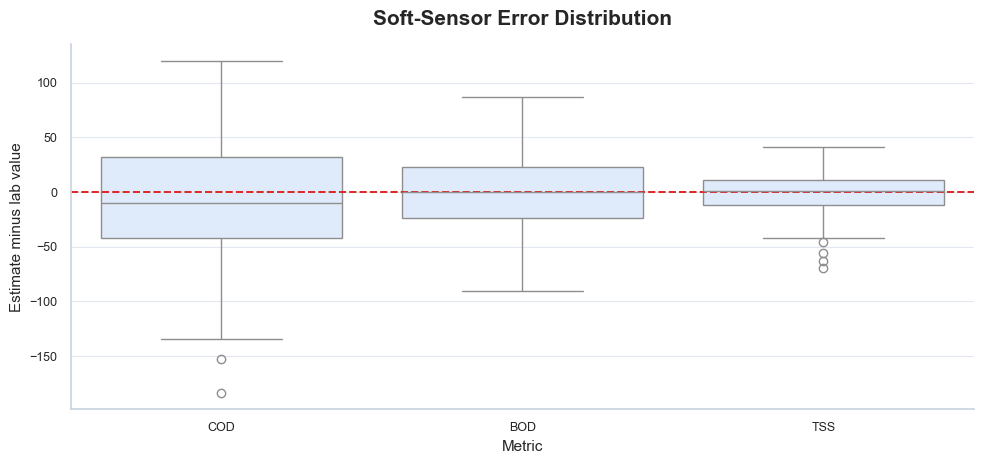

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
BOD,135.000,29.210,22.380,0.550,11.140,23.720,45.130,90.080
COD,135.000,46.020,34.060,0.320,20.850,39.130,64.280,183.480
TSS,135.000,15.700,13.120,0.820,5.870,11.110,24.050,69.740


In [19]:
validation_long = []
for actual, predicted, label in pairs:
    temp = validation[["timestamp", "event_type", actual, predicted]].copy()
    temp["metric"] = label
    temp["error"] = temp[predicted] - temp[actual]
    temp["absolute_error"] = temp["error"].abs()
    validation_long.append(temp[["timestamp", "event_type", "metric", "error", "absolute_error"]])

validation_long = pd.concat(validation_long, ignore_index=True)

plt.figure(figsize=(10, 4.8))
sns.boxplot(data=validation_long, x="metric", y="error", color="#DBEAFE")
plt.axhline(0, color=COLORS["red"], linestyle="--", linewidth=1.4)
finish_plot("Soft-Sensor Error Distribution", "Metric", "Estimate minus lab value", legend=False)
plt.show()

validation_long.groupby("metric")["absolute_error"].describe().round(2)

## 15. Value Source Mix

The dashboard should distinguish lab-confirmed values from soft-sensor estimates.
This confirms how often the operational dataset uses each source.

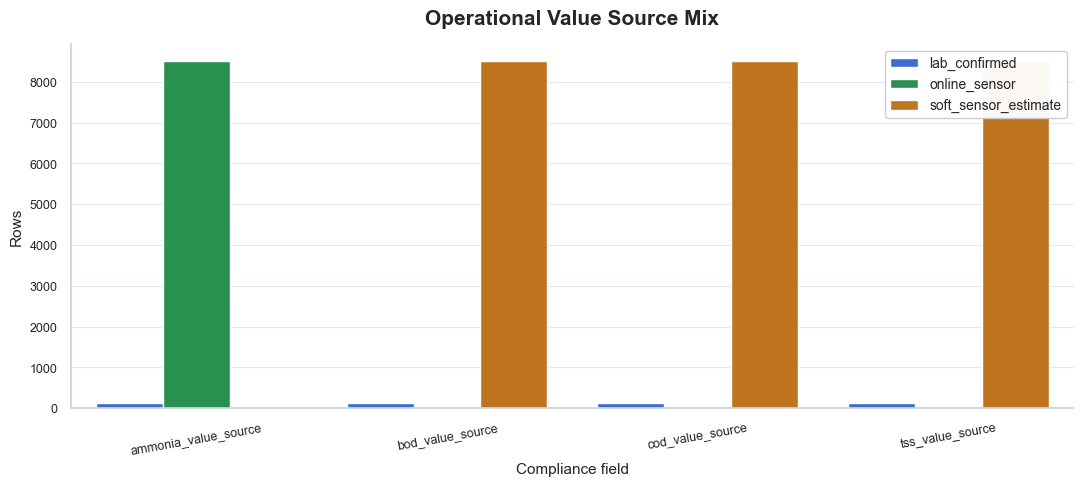

,metric,source,rows
0,ammonia_value_source,lab_confirmed,135
1,ammonia_value_source,online_sensor,8505
2,bod_value_source,lab_confirmed,135
3,bod_value_source,soft_sensor_estimate,8505
4,cod_value_source,lab_confirmed,135
5,cod_value_source,soft_sensor_estimate,8505
6,tss_value_source,lab_confirmed,135
7,tss_value_source,soft_sensor_estimate,8505


In [20]:
source_cols = ["cod_value_source", "bod_value_source", "tss_value_source", "ammonia_value_source"]
source_counts = (
    operational[source_cols]
    .melt(var_name="metric", value_name="source")
    .groupby(["metric", "source"])
    .size()
    .reset_index(name="rows")
)

plt.figure(figsize=(11, 4.8))
sns.barplot(data=source_counts, x="metric", y="rows", hue="source", palette=[COLORS["blue"], COLORS["green"], COLORS["amber"]])
finish_plot("Operational Value Source Mix", "Compliance field", "Rows", legend=True)
plt.xticks(rotation=10)
plt.show()

source_counts

## 16. Correlation Structure

Correlations reveal which real-time proxy sensors move with estimated compliance values.
This is especially important for COD/BOD/TSS soft-sensor logic.

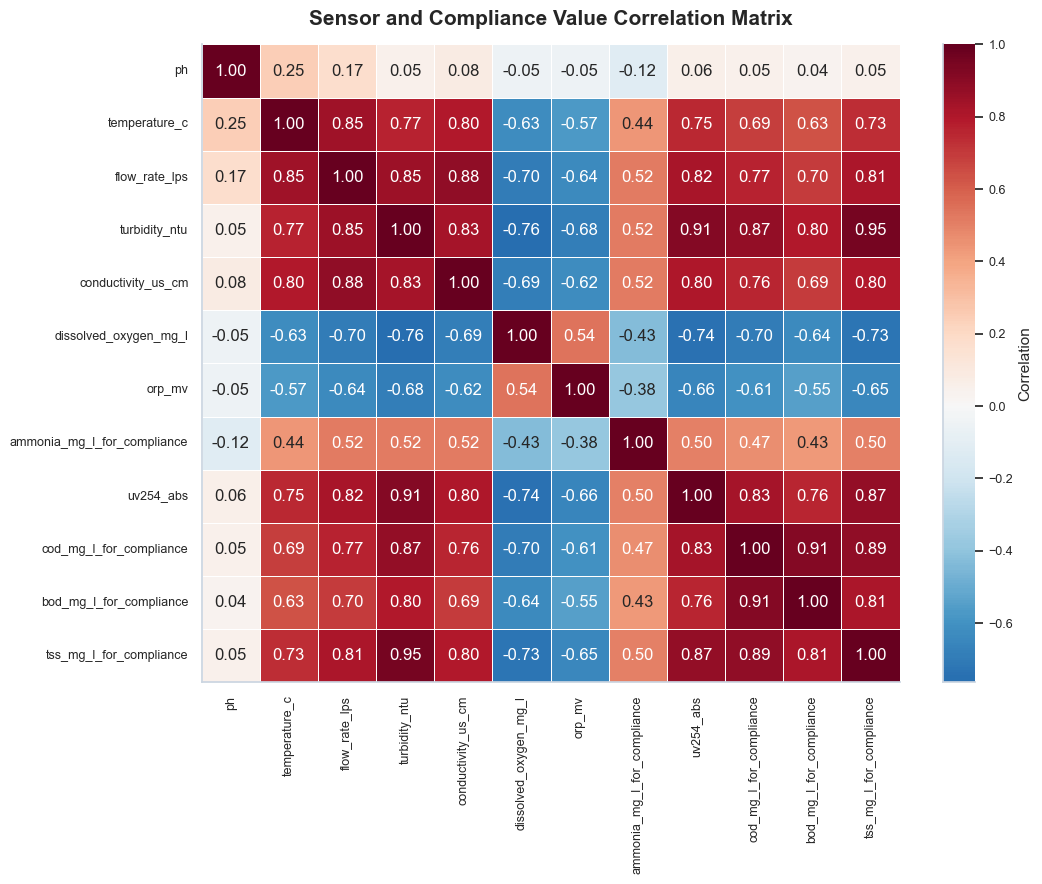

In [21]:
corr_cols = [
    "ph", "temperature_c", "flow_rate_lps", "turbidity_ntu",
    "conductivity_us_cm", "dissolved_oxygen_mg_l", "orp_mv",
    "ammonia_mg_l_for_compliance", "uv254_abs",
    "cod_mg_l_for_compliance", "bod_mg_l_for_compliance", "tss_mg_l_for_compliance",
]

corr = operational[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5, cbar_kws={"label": "Correlation"})
finish_plot("Sensor and Compliance Value Correlation Matrix", "", "", legend=False)
plt.show()

## 17. Cross-Correlation With Organic Load Proxies

Cross-correlation helps test whether UV254 and turbidity lead or track COD/BOD estimates.
Positive lags below mean the proxy sensor is shifted into the past to test leading behaviour.

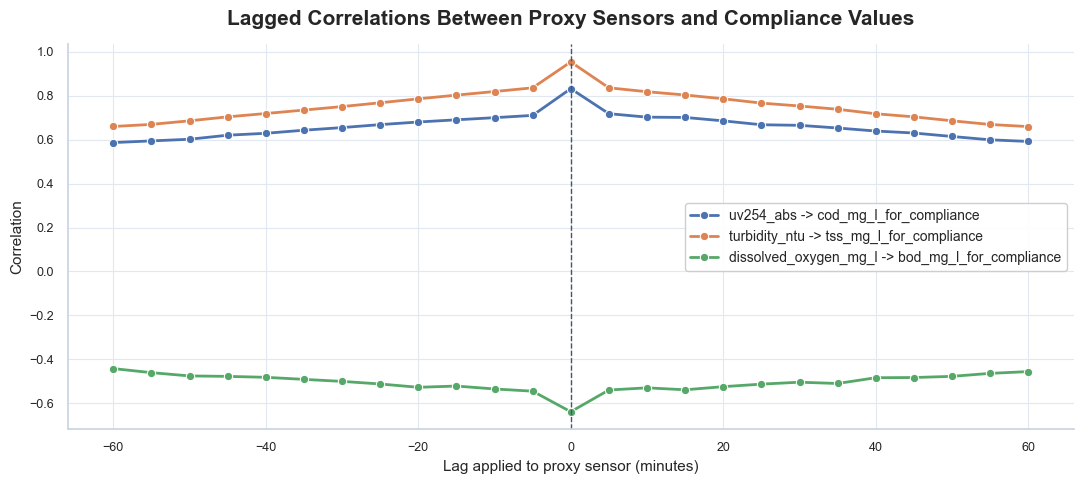

,lag_minutes,correlation,proxy,target,pair
50,-60,-0.443,dissolved_oxygen_mg_l,bod_mg_l_for_compliance,dissolved_oxygen_mg_l -> bod_mg_l_for_compliance
37,0,0.954,turbidity_ntu,tss_mg_l_for_compliance,turbidity_ntu -> tss_mg_l_for_compliance
12,0,0.833,uv254_abs,cod_mg_l_for_compliance,uv254_abs -> cod_mg_l_for_compliance


In [22]:
def lagged_corr(frame, x, y, max_lag_steps=12):
    rows = []
    for lag in range(-max_lag_steps, max_lag_steps + 1):
        rows.append({
            "lag_minutes": lag * 5,
            "correlation": frame[x].shift(lag).corr(frame[y]),
            "proxy": x,
            "target": y,
        })
    return pd.DataFrame(rows)

cc = pd.concat([
    lagged_corr(operational, "uv254_abs", "cod_mg_l_for_compliance"),
    lagged_corr(operational, "turbidity_ntu", "tss_mg_l_for_compliance"),
    lagged_corr(operational, "dissolved_oxygen_mg_l", "bod_mg_l_for_compliance"),
], ignore_index=True)
cc["pair"] = cc["proxy"] + " -> " + cc["target"]

plt.figure(figsize=(11, 5))
sns.lineplot(data=cc, x="lag_minutes", y="correlation", hue="pair", marker="o", linewidth=2)
plt.axvline(0, color=COLORS["slate"], linestyle="--", linewidth=1)
finish_plot("Lagged Correlations Between Proxy Sensors and Compliance Values", "Lag applied to proxy sensor (minutes)", "Correlation")
plt.show()

cc.loc[cc.groupby("pair")["correlation"].idxmax()].sort_values("pair")

## 18. Rolling Volatility

Rolling standard deviation highlights unstable periods and sensor noise.
High volatility can be an early warning signal even before a limit is crossed.

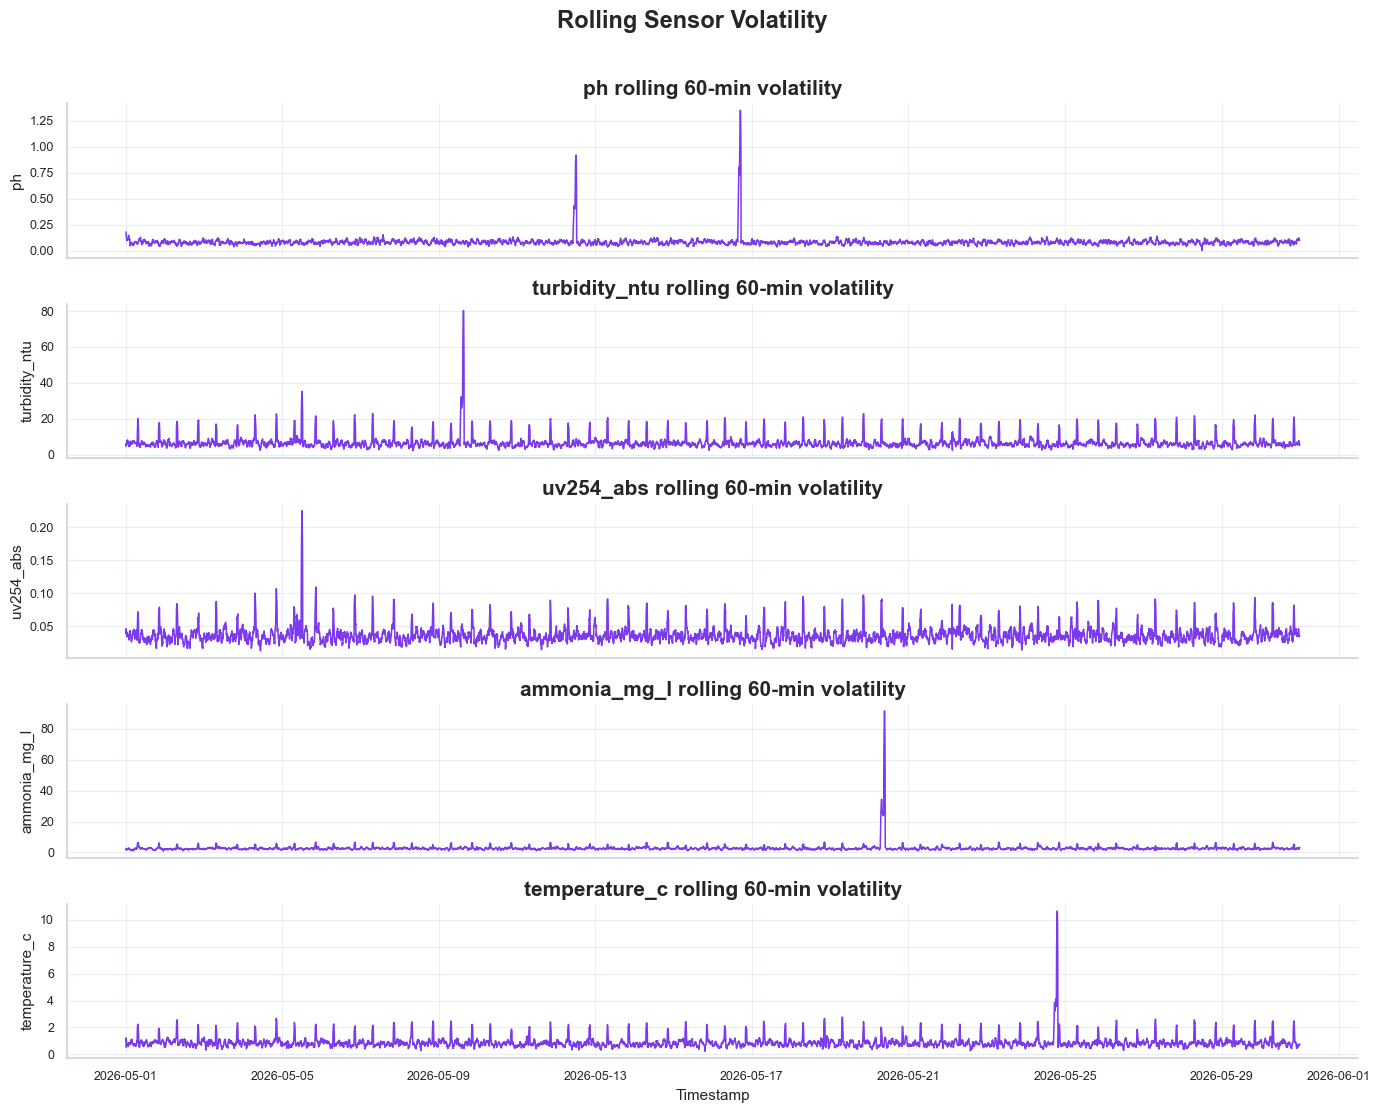

In [23]:
volatility_cols = ["ph", "turbidity_ntu", "uv254_abs", "ammonia_mg_l", "temperature_c"]
vol = sensors.set_index("timestamp")[volatility_cols].rolling("60min").std()

fig, axes = plt.subplots(len(volatility_cols), 1, figsize=(14, 11), sharex=True)
for ax, col in zip(axes, volatility_cols):
    ax.plot(vol.index, vol[col], color=COLORS["purple"], linewidth=1.1)
    ax.set_ylabel(col)
    ax.set_title(f"{col} rolling 60-min volatility", weight="bold")
    ax.grid(True, alpha=0.7)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Rolling Sensor Volatility", fontsize=17, weight="bold", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

## 19. Daily Operating Pattern

Industrial wastewater often follows production schedules. Hour-of-day profiles help reveal
normal cycles that models should learn instead of treating them as anomalies.

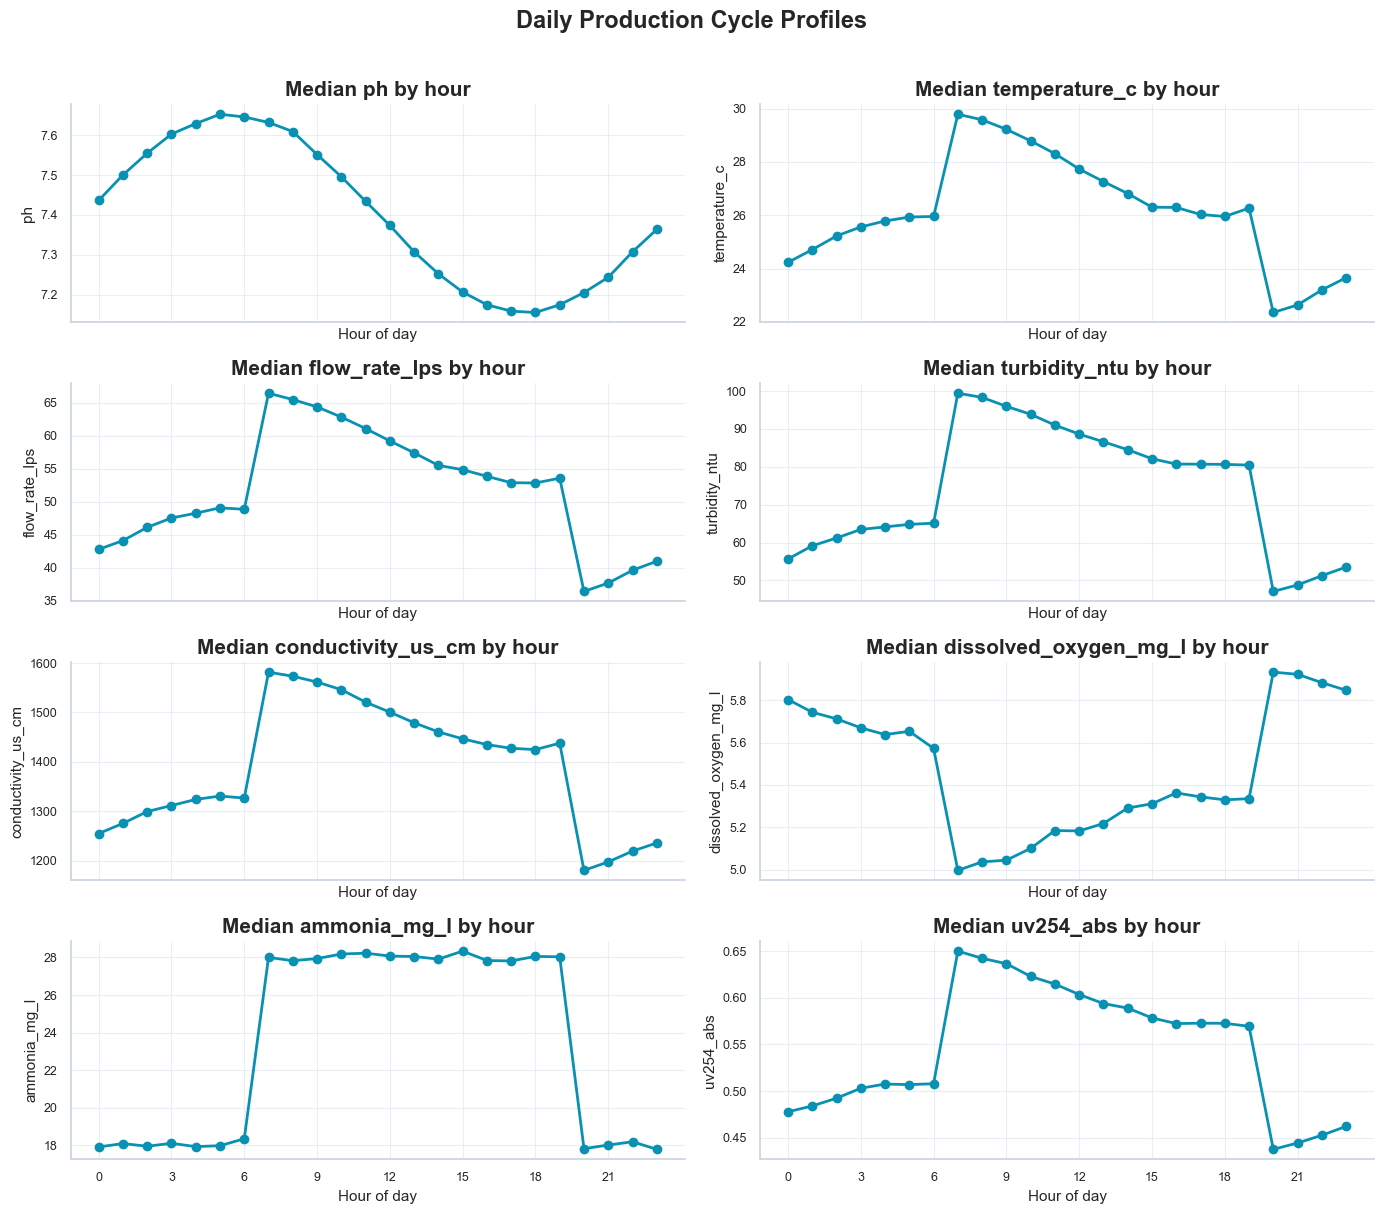

In [24]:
hourly = sensors.assign(hour=sensors["timestamp"].dt.hour).groupby("hour")[plot_cols].median()

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for ax, col in zip(axes.ravel(), plot_cols):
    ax.plot(hourly.index, hourly[col], marker="o", color=COLORS["cyan"], linewidth=2)
    ax.set_title(f"Median {col} by hour", weight="bold")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel(col)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.7)

fig.suptitle("Daily Production Cycle Profiles", fontsize=17, weight="bold", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

## 20. Fourier Analysis

Fourier analysis highlights dominant periodicity. Peaks around 24 hours support the presence
of a daily production cycle in the telemetry.

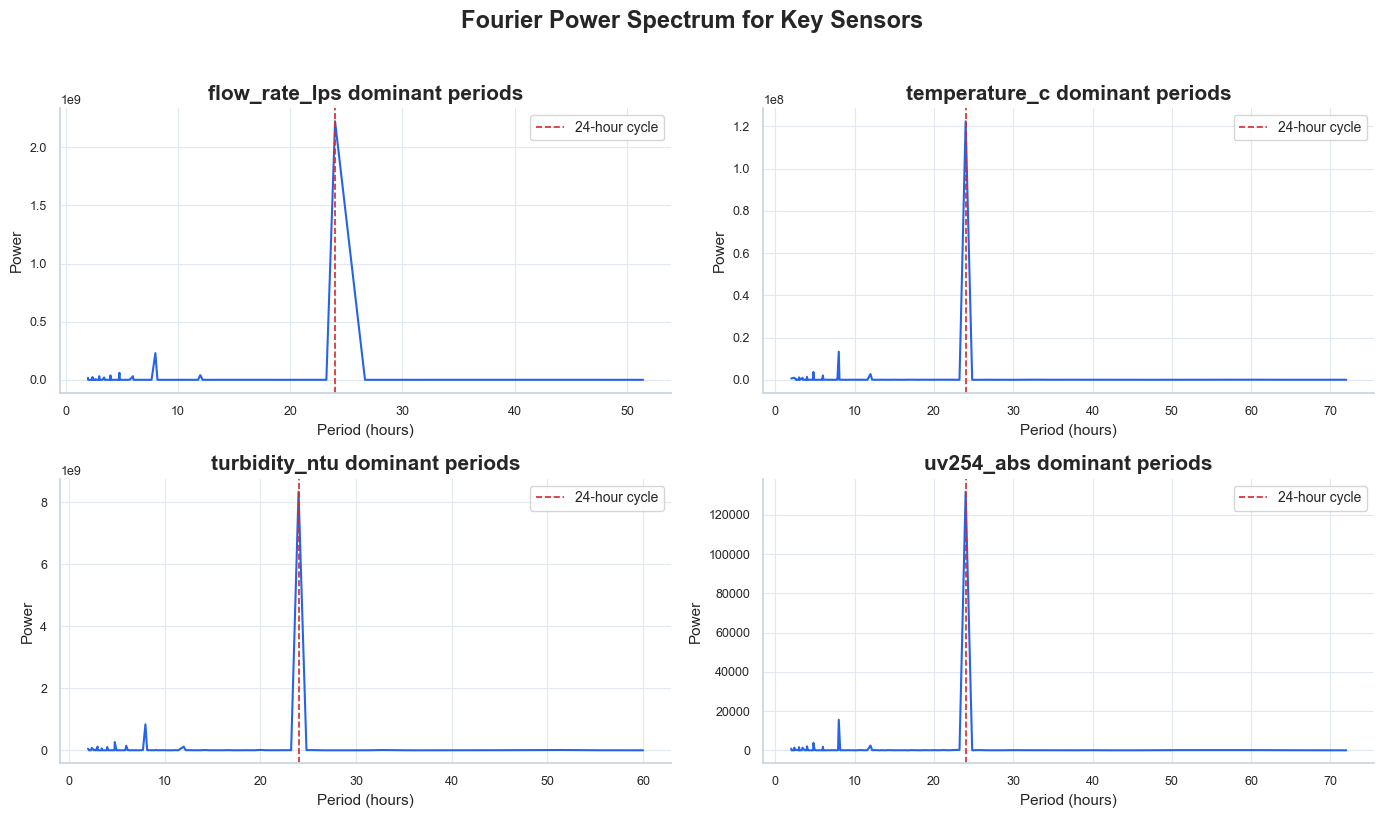

,sensor,period_hours,power
30,flow_rate_lps,24.000,"2,224,657,329.120"
90,flow_rate_lps,8.000,"229,904,804.320"
150,flow_rate_lps,4.800,"60,526,859.240"
60,flow_rate_lps,12.000,"40,694,089.110"
180,flow_rate_lps,4.000,"37,933,479.270"
30,temperature_c,24.000,"122,409,638.810"
90,temperature_c,8.000,"13,354,343.050"
150,temperature_c,4.800,"3,779,370.780"
60,temperature_c,12.000,"2,784,311.780"
120,temperature_c,6.000,"2,100,079.780"


In [25]:
def fourier_power(series, sample_minutes=5):
    clean = series.interpolate(limit_direction="both").to_numpy()
    clean = clean - clean.mean()
    power = np.abs(np.fft.rfft(clean)) ** 2
    freq = np.fft.rfftfreq(len(clean), d=sample_minutes / 60)
    result = pd.DataFrame({"frequency_per_hour": freq, "power": power})
    result = result[result["frequency_per_hour"] > 0].copy()
    result["period_hours"] = 1 / result["frequency_per_hour"]
    return result

fft_cols = ["flow_rate_lps", "temperature_c", "turbidity_ntu", "uv254_abs"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.ravel(), fft_cols):
    power = fourier_power(sensors[col])
    view = power[power["period_hours"].between(2, 72)].nlargest(120, "power").sort_values("period_hours")
    ax.plot(view["period_hours"], view["power"], color=COLORS["blue"], linewidth=1.5)
    ax.axvline(24, color=COLORS["red"], linestyle="--", linewidth=1.2, label="24-hour cycle")
    ax.set_title(f"{col} dominant periods", weight="bold")
    ax.set_xlabel("Period (hours)")
    ax.set_ylabel("Power")
    ax.legend(frameon=True)

fig.suptitle("Fourier Power Spectrum for Key Sensors", fontsize=17, weight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

dominant_periods = []
for col in fft_cols:
    power = fourier_power(sensors[col])
    dominant = power[power["period_hours"].between(2, 72)].nlargest(5, "power")
    dominant["sensor"] = col
    dominant_periods.append(dominant[["sensor", "period_hours", "power"]])

pd.concat(dominant_periods).sort_values(["sensor", "power"], ascending=[True, False]).round(2)

## 21. Autocorrelation

Autocorrelation shows how much each signal resembles its own recent history.
Strong short-lag autocorrelation supports lag and rolling-window features.

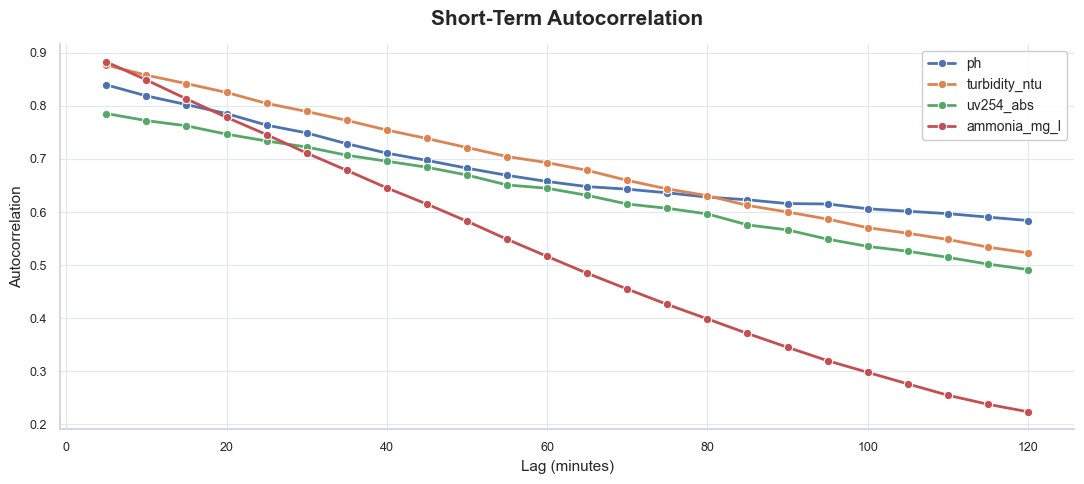

In [26]:
def autocorr_values(series, max_lag_steps=24):
    return pd.DataFrame({
        "lag_minutes": np.arange(1, max_lag_steps + 1) * 5,
        "autocorrelation": [series.autocorr(lag=i) for i in range(1, max_lag_steps + 1)],
    })

ac = pd.concat(
    [autocorr_values(sensors[col].interpolate()).assign(sensor=col) for col in ["ph", "turbidity_ntu", "uv254_abs", "ammonia_mg_l"]],
    ignore_index=True,
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=ac, x="lag_minutes", y="autocorrelation", hue="sensor", marker="o", linewidth=2)
finish_plot("Short-Term Autocorrelation", "Lag (minutes)", "Autocorrelation")
plt.show()

## 22. Breach Lead-Time Windows

Inspect the rows immediately before breaches. These are the moments the model should learn
to identify as early warnings.

In [27]:
first_breach_mask = operational["breach_now"] & ~operational["breach_now"].shift(1, fill_value=False)
first_breaches = operational.loc[first_breach_mask, ["timestamp", "event_type", "current_breach_reason", "main_risk_driver"]]

windows = []
for _, breach in first_breaches.iterrows():
    start = breach["timestamp"] - pd.Timedelta(minutes=60)
    end = breach["timestamp"]
    temp = operational[operational["timestamp"].between(start, end)].copy()
    temp["minutes_to_breach"] = (breach["timestamp"] - temp["timestamp"]).dt.total_seconds() / 60
    temp["breach_time"] = breach["timestamp"]
    windows.append(temp)

breach_windows = pd.concat(windows, ignore_index=True) if windows else pd.DataFrame()
first_breaches.head(), first_breaches.shape

(               timestamp        event_type current_breach_reason  \
 1289 2026-05-05 11:25:00  organic_overload         COD above max   
 2465 2026-05-09 13:25:00    solids_washout         TSS above max   
 2468 2026-05-09 13:40:00    solids_washout         TSS above max   
 3302 2026-05-12 11:10:00        acid_spill          pH below min   
 4516 2026-05-16 16:20:00      alkali_spill          pH above max   
 
      main_risk_driver  
 1289              COD  
 2465              TSS  
 2468              TSS  
 3302           pH low  
 4516          pH high  ,
 (7, 4))

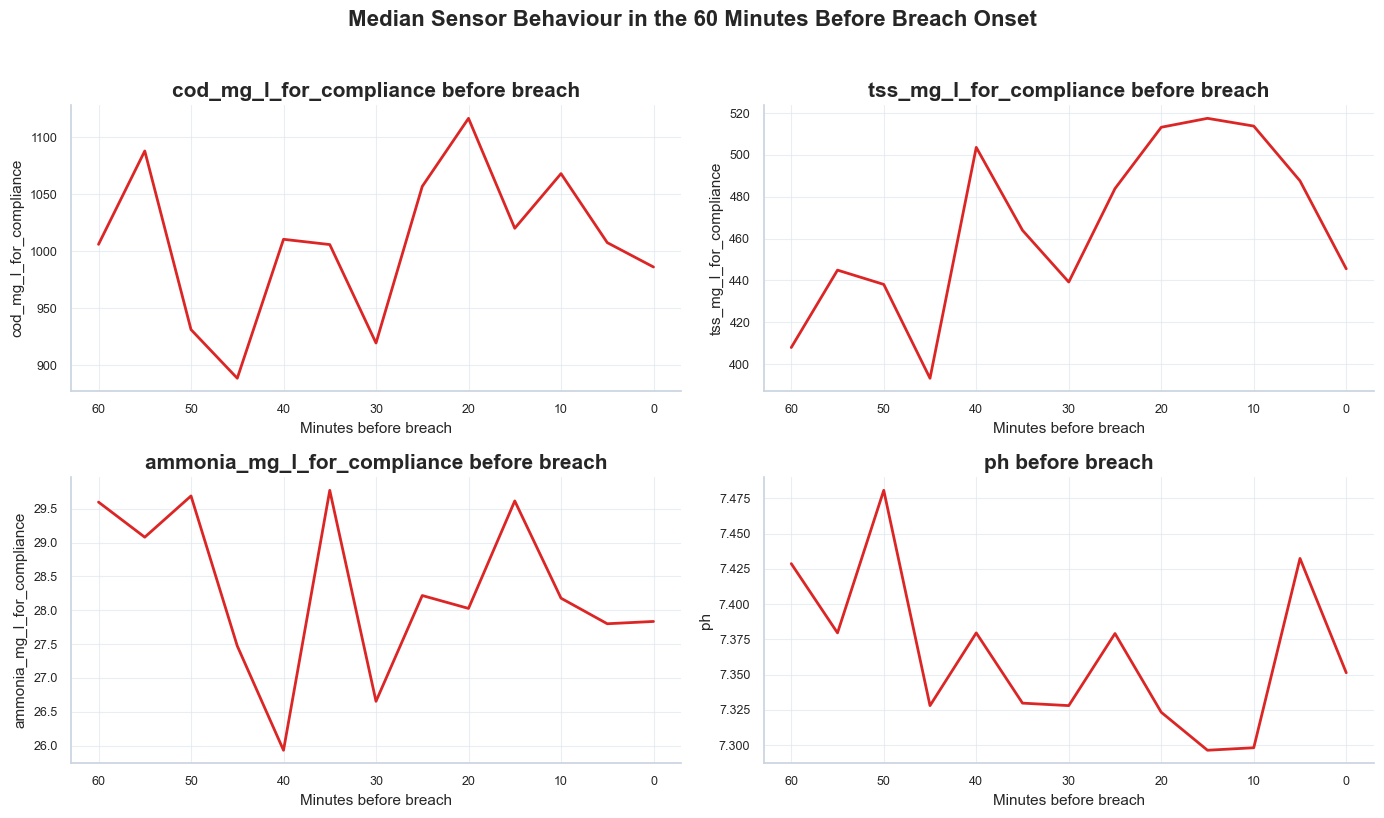

In [28]:
if len(breach_windows):
    lead_profile = breach_windows.groupby("minutes_to_breach")[
        ["cod_mg_l_for_compliance", "tss_mg_l_for_compliance", "ammonia_mg_l_for_compliance", "ph"]
    ].median().sort_index(ascending=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, col in zip(axes.ravel(), lead_profile.columns):
        ax.plot(lead_profile.index, lead_profile[col], color=COLORS["red"], linewidth=2)
        ax.invert_xaxis()
        ax.set_title(f"{col} before breach", weight="bold")
        ax.set_xlabel("Minutes before breach")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.7)

    fig.suptitle("Median Sensor Behaviour in the 60 Minutes Before Breach Onset", fontsize=16, weight="bold", y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No breach onset windows found.")

## 23. Data Leakage Checks

Features must only use current and past information. Future breach targets are labels,
not inputs. This check lists columns that should be excluded from model features.

In [29]:
leakage_like_cols = [
    col for col in model_df.columns
    if col.startswith("breach_next_")
    or col in ["breach_now", "compliance_status", "current_breach_reason", "breached_parameters", "recommended_action"]
]

pd.DataFrame({"exclude_from_features": leakage_like_cols})

,exclude_from_features
0,breach_now
1,compliance_status
2,breached_parameters
3,current_breach_reason
4,recommended_action
5,breach_next_15min
6,breach_next_30min
7,breach_next_60min


## 24. Forensic Findings Summary

This final table captures the headline findings for reports and modelling decisions.

In [30]:
findings = pd.DataFrame([
    ("Cadence", f"Most common interval is {sensors['timestamp'].sort_values().diff().dropna().mode().iloc[0]}."),
    ("Missingness", f"{int(sensors[sensor_cols].isna().sum().sum())} total missing direct-sensor values, concentrated in the injected missing burst."),
    ("Compliance rarity", f"RED rows are {(operational['compliance_status'].eq('RED').mean() * 100):.2f}% of operational records."),
    ("Prediction rarity", f"30-minute future breach positives are {(model_df['breach_next_30min'].mean() * 100):.2f}% of model records."),
    ("Soft sensors", f"COD R2={metrics.loc['COD', 'R2']:.3f}, BOD R2={metrics.loc['BOD', 'R2']:.3f}, TSS R2={metrics.loc['TSS', 'R2']:.3f} against lab samples."),
    ("Seasonality", "Fourier analysis shows dominant operating cycles that should be considered in modelling."),
    ("Feature direction", "Lag and rolling-window features are justified by strong short-term autocorrelation and incident lead-up behaviour."),
], columns=["area", "finding"])

findings

,area,finding
0,Cadence,Most common interval is 0 days 00:05:00.
1,Missingness,"30 total missing direct-sensor values, concent..."
2,Compliance rarity,RED rows are 0.38% of operational records.
3,Prediction rarity,30-minute future breach positives are 0.75% of...
4,Soft sensors,"COD R2=0.909, BOD R2=0.883, TSS R2=0.971 again..."
5,Seasonality,Fourier analysis shows dominant operating cycl...
6,Feature direction,Lag and rolling-window features are justified ...
